# Does post-hoc calibration help? Comparing six calibration maps with cross-validation

**Question.** A Random Forest trained on the UCI Heart Disease (Cleveland) data discriminates well (AUC ≈ 0.9). Are its probabilities also *trustworthy*, and does a post-hoc calibration map make them better **in a way that survives proper validation**?

**What this notebook does**

1. Compares six calibration maps of increasing flexibility: none, temperature scaling, Platt (sigmoid), logistic recalibration, beta calibration and isotonic regression.
2. Fits every map with **cross-fitting** (out-of-fold predictions), so no record is set aside only for calibration and no map sees in-sample probabilities.
3. Compares the maps with **5×5 repeated stratified CV** on the development set and selects one with a **pre-specified one-standard-error rule**.
4. Evaluates all maps **once** on a held-out test set (reliability diagrams, Brier, log loss, calibration intercept/slope, paired bootstrap).
5. Estimates the performance of the **whole procedure, selection included,** with **nested CV** (5×3 outer, 5×2 inner).

**Key findings**

- The uncalibrated forest is **under-confident**: its calibration slope is above 1 (≈ 1.6 in CV), i.e. its probabilities are too close to 0.5.
- The parametric maps (temperature, Platt, logistic, beta) fix most of the slope problem, but the gain in Brier score is **small** (≈ 0.001 in development CV, ≈ 0.002 in nested CV), comparable to the split-to-split noise. Isotonic regression **overfits** with ~190 training records.
- On the single held-out test split, the parametric maps look clearly better (Brier 0.100 → 0.090, bootstrap CI excluding 0). **Nested CV shows that this split was favourable**: a gain that large is not typical.
- The pre-specified rule keeps the **uncalibrated** model in 14 of 15 outer folds. Classification at a 0.50 threshold is identical.
- Takeaway: **evaluate calibration with resampling, not one split**, and pre-register how a calibration method will be chosen.

Reusable code lives in [`src/heartcal`](../src/heartcal) and is unit-tested in [`tests/`](../tests); this notebook tells the story.

## 1 Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import platform

import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split

from heartcal import plotting
from heartcal.calibrators import CALIBRATORS
from heartcal.data import FEATURE_DESCRIPTIONS, CATEGORICAL, load_cleveland
from heartcal.experiment import (
    crossfit, nested_cv, paired_differences, repeated_cv, select_method, summarize_cv,
)
from heartcal.metrics import (
    brier_skill_score, classification_metrics, log_loss, paired_bootstrap, probability_metrics,
)

SEED = 42
plotting.set_style()
pd.set_option("display.precision", 4)
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__)

Python 3.14.0 | scikit-learn 1.7.2


## 2 Data

Source: [UCI Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease), file `processed.cleveland.data` (DOI [10.24432/C52P4X](https://doi.org/10.24432/C52P4X), CC BY 4.0). A copy ships in `data/`; the loader checks its SHA-256 so the analysis always reads the same bytes. `?` marks missing values.

**Outcome.** `num` ranges from 0 to 4; we model **presence of disease** (`num > 0`). It is a *diagnostic* outcome recorded at the same time as the exam variables, not the prediction of a future event.

In [2]:
X, y = load_cleveland()
print(f"{X.shape[0]} records, {X.shape[1]} predictors, disease prevalence {y.mean():.1%}")
pd.DataFrame({
    "description": pd.Series(FEATURE_DESCRIPTIONS),
    "type": pd.Series({c: "categorical" if c in CATEGORICAL else "numeric" for c in X.columns}),
    "missing": X.isna().sum(),
})

303 records, 13 predictors, disease prevalence 45.9%


,description,type,missing
age,Age in years,numeric,0
sex,"Recorded sex (0 = female, 1 = male)",categorical,0
cp,Chest pain type (1-4),categorical,0
trestbps,Resting blood pressure (mmHg),numeric,0
chol,Serum cholesterol (mg/dL),numeric,0
fbs,Fasting blood sugar > 120 mg/dL (0/1),categorical,0
restecg,Resting ECG result (0-2),categorical,0
thalach,Maximum heart rate achieved,numeric,0
exang,Exercise-induced angina (0/1),categorical,0
oldpeak,ST depression induced by exercise relative to ...,numeric,0


Codes such as `thal` (3, 6, 7) are categories, not a scale, so they are one-hot encoded. `ca` is kept numeric because it is a count. Imputation (median / most frequent) and encoding are fitted inside the model pipeline, only ever on training data.

## 3 Study design

```
303 records
├── Test set (20%, stratified) ─────────────── touched once, at the end (Section 7)
└── Development set (80%)
    ├── 5×5 repeated stratified CV ─────────── compare the six maps, select one (Sections 5-6)
    │     └── inside each training fold: cross-fitting
    │           internal 5-fold CV → out-of-fold probabilities → fit every calibration map
    │           base model refitted on the whole training fold
    └── Final fit with the same cross-fitting → predict the test set

Nested CV (Section 9): the whole procedure (cross-fitting + selection) repeated
inside 5×3 outer folds over all 303 records.
```

**Why cross-fitting?** A map fitted on the model's in-sample probabilities learns the model's overfitting, not its calibration. The classic alternative, a dedicated calibration split, wastes data that a 303-record study cannot afford. Cross-fitting uses every development record for both the model and the map. It is what `CalibratedClassifierCV(ensemble=False)` does, and the unit tests check that our implementation reproduces it.

**Base model.** A Random Forest (300 trees, `min_samples_leaf=3`) with hyperparameters fixed in advance. There is no tuning, so no tuning can leak into the comparison.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
pd.DataFrame({"records": [len(y_dev), len(y_test)], "events": [y_dev.sum(), y_test.sum()],
              "prevalence": [y_dev.mean(), y_test.mean()]}, index=["Development", "Test"])

,records,events,prevalence
Development,242,111,0.4587
Test,61,28,0.4590


## 4 The calibration maps

| Method | Parameters | Map | Can fix |
|---|---|---|---|
| Uncalibrated | 0 | $p' = p$ | — |
| Temperature scaling | 1 | $\operatorname{logit} p' = \operatorname{logit}(p)/T$ | over/under-confidence, not a shift |
| Platt (sigmoid) | 2 | $\operatorname{logit} p' = a\,p + b$ | scikit-learn's `"sigmoid"` on probabilities |
| Logistic recalibration | 2 | $\operatorname{logit} p' = a + b\,\operatorname{logit}(p)$ | shift + spread on the logit scale |
| Beta calibration | 3 | $\operatorname{logit} p' = c + a\ln p - b\ln(1-p)$ | asymmetric distortion of the two tails |
| Isotonic regression | many | monotone step function | any monotone distortion (needs more data) |

All maps are monotone, so they cannot change the ranking of patients. AUC is unchanged, except for ties created by isotonic steps. Logistic recalibration is the same model used to *measure* the calibration intercept and slope, used here as a correction.

**Sanity check against scikit-learn.** Cross-fitting followed by our isotonic and Platt maps should match `CalibratedClassifierCV(ensemble=False)`:

In [4]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from heartcal.modeling import make_model

check = crossfit(X_dev, y_dev, X_test, seed=SEED)
for method, ours in [("isotonic", "Isotonic regression"), ("sigmoid", "Platt (sigmoid)")]:
    sk = CalibratedClassifierCV(make_model(SEED), method=method, ensemble=False,
                                cv=StratifiedKFold(5, shuffle=True, random_state=SEED))
    gap = np.abs(sk.fit(X_dev, y_dev).predict_proba(X_test)[:, 1] - check.proba[ours]).max()
    print(f"{ours:<22} max |ours - scikit-learn| = {gap:.1e}")

Isotonic regression    max |ours - scikit-learn| = 0.0e+00


Platt (sigmoid)        max |ours - scikit-learn| = 8.9e-05


## 5 Comparing the maps with repeated cross-validation

Each of the 25 splits (5 folds × 5 repeats) trains the forest and all six maps on four fifths of the development set and scores the remaining fifth. Every map is evaluated on **the same records in every split**, so the comparisons are paired.

Metrics:

- **Brier score** and **log loss**: overall quality of the probabilities; lower is better. Log loss punishes confident mistakes heavily (probabilities are clipped to [1e-6, 1 − 1e-6]).
- **Calibration intercept**: target 0. Calibration-in-the-large, estimated with the slope fixed at 1.
- **Calibration slope**: target 1. Above 1 = predictions too moderate, below 1 = too extreme.
- **AUC**: discrimination only; included to show it does not move.

In [5]:
cv = repeated_cv(X_dev, y_dev, n_splits=5, n_repeats=5, seed=SEED)
summarize_cv(cv)

brier         log_loss             auc          \
                          mean     std     mean     std    mean     std   
method                                                                    
Uncalibrated            0.1338  0.0215   0.4179  0.0494  0.8926  0.0414   
Temperature scaling     0.1325  0.0265   0.4093  0.0672  0.8926  0.0414   
Platt (sigmoid)         0.1340  0.0274   0.4160  0.0671  0.8926  0.0414   
Logistic recalibration  0.1328  0.0266   0.4095  0.0676  0.8926  0.0414   
Beta calibration        0.1330  0.0267   0.4127  0.0695  0.8926  0.0414   
Isotonic regression     0.1375  0.0292   0.4855  0.1363  0.8884  0.0444   

                       cal_intercept         cal_slope          
                                mean     std      mean     std  
method                                                          
Uncalibrated                 -0.0147  0.1807    1.5595  0.6630  
Temperature scaling           0.0379  0.2642    1.1501  0.5070  
Platt (sigmoid)              -0.0223  0.2671    1.1764  0.4493  
Logistic recalibration       -0.0232  0.2730    1.1417  0.5015  
Beta calibration             -0.0306  0.2704    1.1346  0.5108  
Isotonic regression          -0.0290  0.3120    0.9573  1.0803

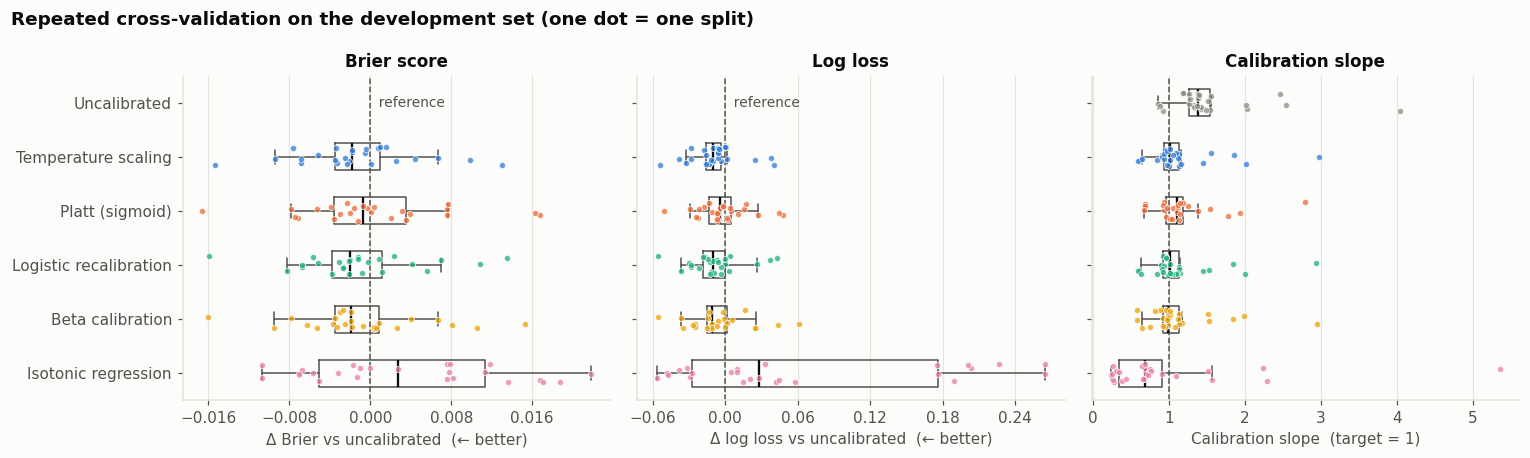

In [6]:
fig = plotting.plot_cv_comparison(cv)

In [7]:
d_brier = paired_differences(cv, "brier")
d_ll = paired_differences(cv, "log_loss")
pd.DataFrame({
    "mean Δ Brier": d_brier.mean(), "splits improved (Brier)": (d_brier < 0).mean(),
    "mean Δ log loss": d_ll.mean(), "splits improved (log loss)": (d_ll < 0).mean(),
}).loc[[m for m in CALIBRATORS if m != "Uncalibrated"]]

,mean Δ Brier,splits improved (Brier),mean Δ log loss,splits improved (log loss)
method,,,,
Temperature scaling,-0.0013,0.64,-0.0086,0.76
Platt (sigmoid),0.0002,0.56,-0.0019,0.60
Logistic recalibration,-0.0010,0.68,-0.0084,0.80
Beta calibration,-0.0008,0.60,-0.0052,0.72
Isotonic regression,0.0037,0.48,0.0676,0.28


**Reading.**

- **The forest is under-confident.** The mean calibration slope of the uncalibrated model is about 1.6. Random Forests average many trees, which pulls probabilities toward the middle.
- **The parametric maps fix the slope** (≈ 1.1-1.2), but the **Brier gain is at most about 0.001** (none for Platt) and goes in the right direction in only 56-68% of the splits. Log loss improves a little more consistently.
- **Isotonic regression overfits.** With ~190 training records its step function is noisy. Its slope varies widely, and its log loss explodes in some splits because it outputs exact 0s and 1s.

## 6 Pre-specified selection: the one-standard-error rule

The rule was fixed before looking at the results. Take the map with the lowest mean CV Brier. Among the maps within one standard error of it, choose **the least flexible**. Extra parameters must earn their place. (Repeated-CV folds are correlated, so the SE is approximate. The rule is a guard against chasing noise, not a significance test.)

In [8]:
selected, selection = select_method(cv, "brier")
print("Selected:", selected)
selection[["mean", "std", "se", "complexity", "within_1se", "best_mean", "selected"]]

Selected: Uncalibrated


,mean,std,se,complexity,within_1se,best_mean,selected
method,,,,,,,
Uncalibrated,0.1338,0.0215,0.0043,0.0,True,False,True
Temperature scaling,0.1325,0.0265,0.0053,1.0,True,True,False
Platt (sigmoid),0.1340,0.0274,0.0055,2.0,True,False,False
Logistic recalibration,0.1328,0.0266,0.0053,2.0,True,False,False
Beta calibration,0.1330,0.0267,0.0053,3.0,True,False,False
Isotonic regression,0.1375,0.0292,0.0058,inf,True,False,False


Temperature scaling has the lowest mean Brier, but every map, including no calibration, lies within one SE of it. The rule therefore keeps the **uncalibrated** model. The development data give no reliable evidence that any map improves the probabilities.

## 7 One look at the held-out test set

All six maps are refitted on the full development set (with cross-fitting) and evaluated once on the 61 test records. The Brier skill score (BSS) compares each map against a constant prediction equal to the development prevalence.

In [9]:
fit = crossfit(X_dev, y_dev, X_test, seed=SEED)
brier_reference = brier_score_loss(y_test, np.full(len(y_test), y_dev.mean()))
test = pd.DataFrame([{"method": m, **probability_metrics(y_test, p)} for m, p in fit.proba.items()])
test["brier_skill"] = brier_skill_score(test["brier"], brier_reference)
test.set_index("method")

,brier,log_loss,auc,ap,mean_predicted,observed_rate,cal_intercept,cal_slope,brier_skill
method,,,,,,,,,
Uncalibrated,0.1000,0.3398,0.9502,0.9344,0.4956,0.459,-0.2350,2.1414,0.5975
Temperature scaling,0.0902,0.3017,0.9502,0.9344,0.4971,0.459,-0.3113,1.5265,0.6366
Platt (sigmoid),0.0895,0.3054,0.9502,0.9344,0.4996,0.459,-0.3225,1.5257,0.6395
Logistic recalibration,0.0902,0.3018,0.9502,0.9344,0.4971,0.459,-0.3111,1.5271,0.6366
Beta calibration,0.0895,0.3037,0.9502,0.9344,0.4999,0.459,-0.3422,1.4111,0.6394
Isotonic regression,0.0961,0.3082,0.9524,0.9214,0.5018,0.459,-0.4391,1.0330,0.6130


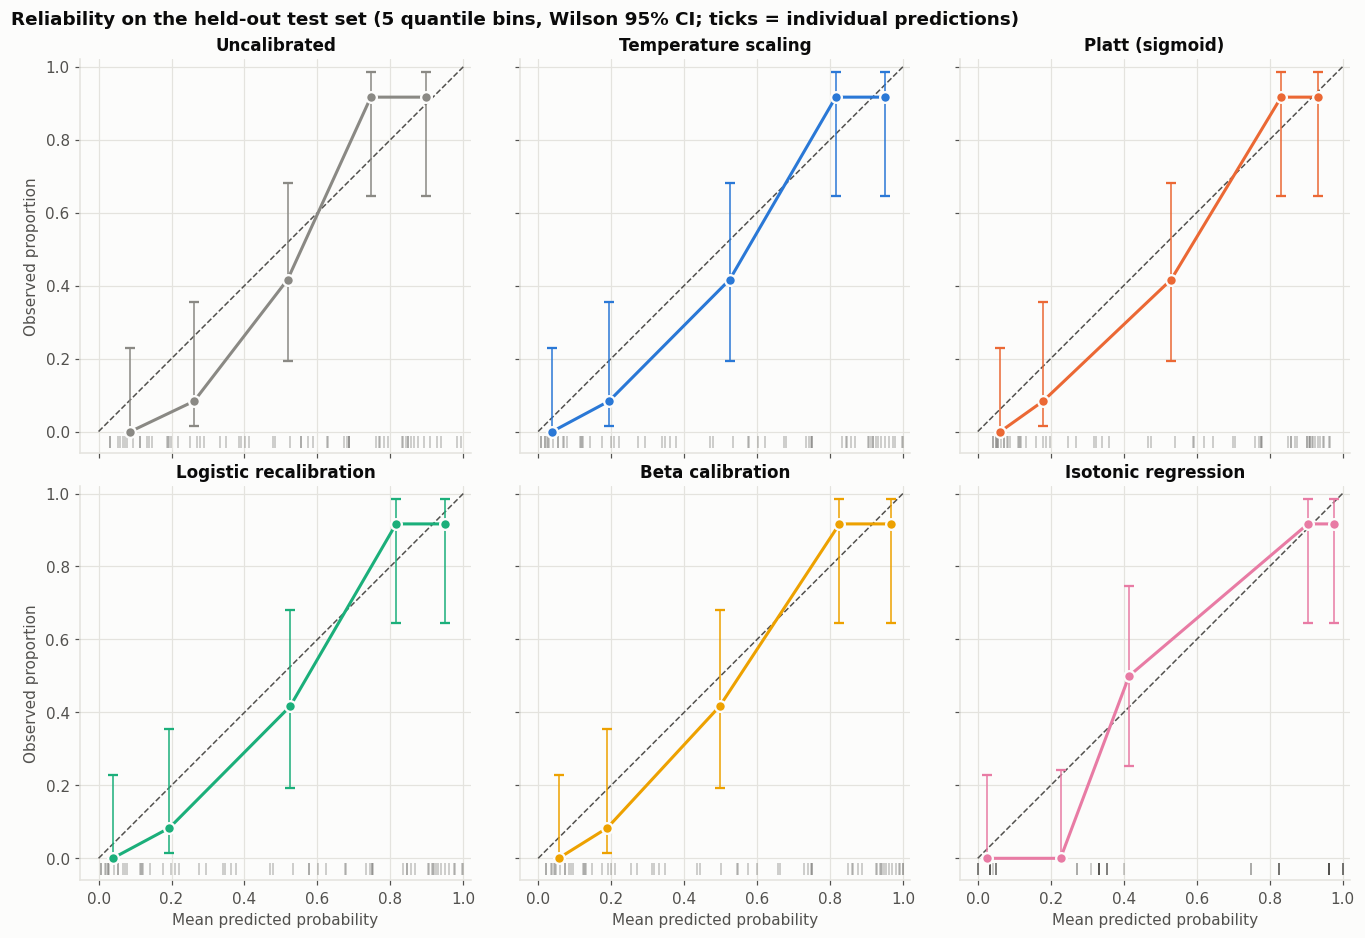

In [10]:
fig = plotting.plot_reliability(y_test, fit.proba)

Below the diagonal = predicted risk too high; above = too low. With ~12 records per bin the Wilson intervals are wide. The uncalibrated curve is S-shaped (too low at the top, too high at the bottom), which is the signature of an under-confident model. The parametric maps straighten it.

**What the maps learned.** Every parametric map stretches probabilities away from 0.5, the correction an under-confident model needs. Isotonic regression learns a jagged staircase from the same data. The fitted logistic recalibration has intercept ≈ 0, so it reduces to temperature scaling (T = 1/b). That is why the two give the same results.

Temperature T = 0.713  (T < 1 sharpens)
Logistic recalibration: a = -0.000, b = 1.402
Beta calibration: {'a': 0.834, 'b': 2.07, 'c': -0.995}


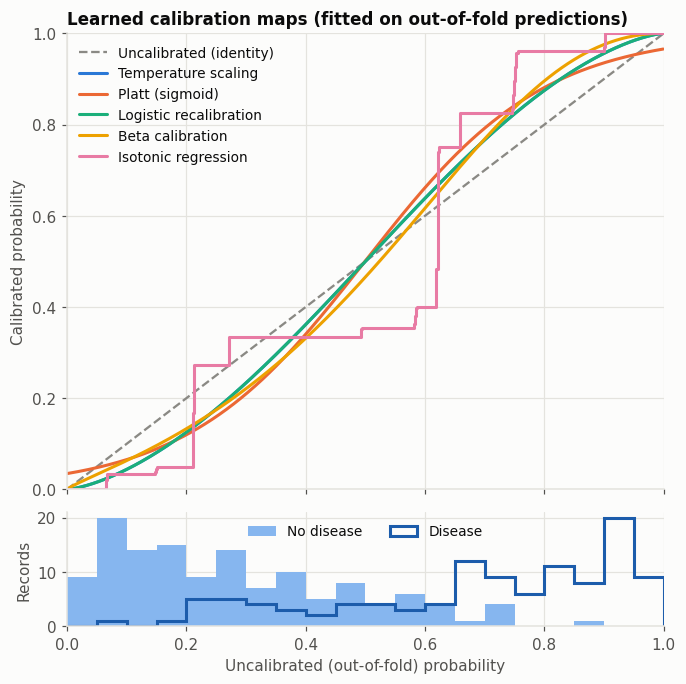

In [11]:
fig = plotting.plot_mappings(fit)
print(f"Temperature T = {fit.calibrators['Temperature scaling'].temperature_:.3f}  (T < 1 sharpens)")
lr = fit.calibrators["Logistic recalibration"].model_
print(f"Logistic recalibration: a = {lr.intercept_[0]:+.3f}, b = {lr.coef_[0, 0]:.3f}")
print("Beta calibration:", {k: round(v, 3) for k, v in fit.calibrators["Beta calibration"].coefficients_.items()})

**Paired bootstrap on the test set.** Each difference is calibrated − uncalibrated (negative = better). The interval is conditional on the fitted models: it reflects the sampling of the 61 test records, not the uncertainty of model development.

In [12]:
rows = []
for m, p in fit.proba.items():
    if m == "Uncalibrated":
        continue
    for metric, fn in [("Brier", brier_score_loss), ("log loss", log_loss)]:
        rows.append({"method": m, "metric": metric,
                     **paired_bootstrap(y_test, fit.proba["Uncalibrated"], p, fn, seed=SEED)})
pd.DataFrame(rows).set_index(["method", "metric"])

difference  ci_low  ci_high
method                 metric                               
Temperature scaling    Brier        -0.0097 -0.0167  -0.0015
                       log loss     -0.0380 -0.0602  -0.0080
Platt (sigmoid)        Brier        -0.0104 -0.0196   0.0002
                       log loss     -0.0344 -0.0609  -0.0022
Logistic recalibration Brier        -0.0097 -0.0167  -0.0015
                       log loss     -0.0380 -0.0602  -0.0080
Beta calibration       Brier        -0.0104 -0.0186  -0.0002
                       log loss     -0.0361 -0.0653   0.0063
Isotonic regression    Brier        -0.0039 -0.0242   0.0180
                       log loss     -0.0316 -0.0897   0.0441

On this split the parametric maps improve the Brier score by about 0.010, and for temperature scaling and logistic recalibration the bootstrap interval excludes zero. **Taken alone, this would suggest recalibrating.** The gain is about ten times larger than in development CV, so Section 9 asks whether it is typical.

## 8 Do the classifications change?

At a fixed 0.50 threshold we compare the uncalibrated model with the best-mean map from CV (temperature scaling). Monotone maps change classifications only for records whose probability crosses the threshold.

,TN,FP,FN,TP,accuracy,sensitivity,specificity,ppv,npv,f1,balanced_accuracy,mcc
Uncalibrated,28.0,5.0,2.0,26.0,0.8852,0.9286,0.8485,0.8387,0.9333,0.8814,0.8885,0.7745
Temperature scaling,28.0,5.0,2.0,26.0,0.8852,0.9286,0.8485,0.8387,0.9333,0.8814,0.8885,0.7745


Records whose class changed: 0


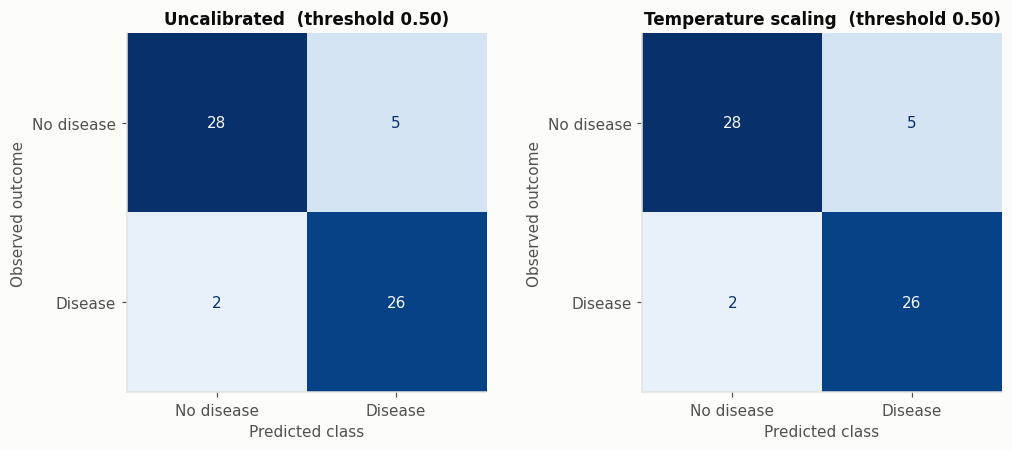

In [13]:
comparator = selection.drop(index="Uncalibrated")["mean"].idxmin()
pair = {"Uncalibrated": fit.proba["Uncalibrated"], comparator: fit.proba[comparator]}
display(pd.DataFrame({m: classification_metrics(y_test, p) for m, p in pair.items()}).T)
crossed = ((pair["Uncalibrated"] >= 0.5) != (pair[comparator] >= 0.5)).sum()
print("Records whose class changed:", crossed)
fig = plotting.plot_confusion(y_test, pair)

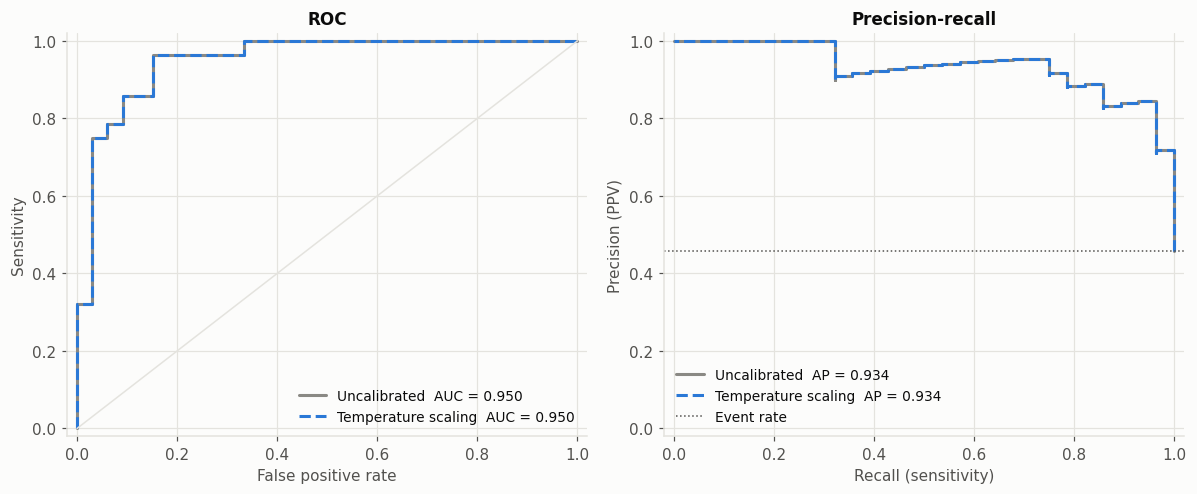

In [14]:
fig = plotting.plot_roc_pr(y_test, pair)

Classification is identical, and the ROC and PR curves overlap because the map preserves the ranking. **Better probabilities and better classifications are different claims.** The first matters when the probability itself is used: risk communication, decision thresholds that differ between users, expected-value calculations.

## 9 Nested cross-validation: is the test-set gain typical?

A single 61-record test split is one draw. Nested CV repeats the **entire procedure** over 15 outer folds of the full dataset: cross-fit the maps, run the inner 5×2 repeated CV, apply the one-SE rule, then score on the outer fold. It estimates how the procedure performs on new data, and how each fixed map would have done.

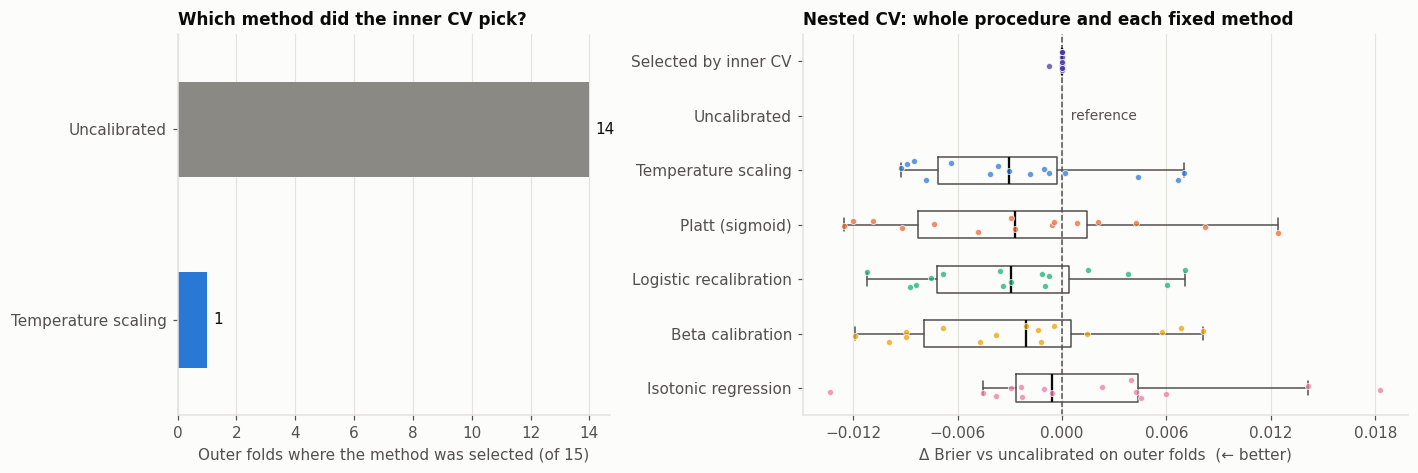

In [15]:
nested = nested_cv(X, y, outer_splits=5, outer_repeats=3, inner_splits=5, inner_repeats=2, seed=SEED)
fig = plotting.plot_nested(nested)

In [16]:
wide = nested.pivot_table(index=["repeat", "fold"], columns="method", values="brier")
procedure = nested[nested["selected"]].set_index(["repeat", "fold"])["brier"]
delta = wide.sub(wide["Uncalibrated"], axis=0)
summary = pd.DataFrame({
    "mean Brier": wide.mean(),
    "mean Δ vs uncalibrated": delta.mean(),
    "outer folds improved": (delta < 0).sum(),
    "mean log loss": nested.groupby("method")["log_loss"].mean(),
}).loc[list(CALIBRATORS)]
summary.loc["Procedure (1-SE selection)"] = [
    procedure.mean(), (procedure - wide["Uncalibrated"]).mean(),
    int(((procedure - wide["Uncalibrated"]) < 0).sum()),
    nested[nested["selected"]]["log_loss"].mean()]
summary.astype({"outer folds improved": int}).round(4)

,mean Brier,mean Δ vs uncalibrated,outer folds improved,mean log loss
method,,,,
Uncalibrated,0.1210,0.0000,0,0.3864
Temperature scaling,0.1186,-0.0025,11,0.3767
Platt (sigmoid),0.1187,-0.0024,10,0.3796
Logistic recalibration,0.1186,-0.0025,11,0.3768
Beta calibration,0.1185,-0.0025,11,0.3804
Isotonic regression,0.1225,0.0015,8,0.4734
Procedure (1-SE selection),0.1210,-0.0001,1,0.3872


**Reading.**

- Applied to unseen data, the parametric maps gain about **0.002-0.003 in Brier** and about 0.01 in log loss, improving roughly two thirds of the outer folds. That is a real but small effect, about four times smaller than the single test split suggested.
- Isotonic regression is the worst option on average: flexibility costs more than it gains at this sample size.
- The one-SE rule keeps the uncalibrated model in 14 of 15 outer folds, so the procedure performs like no calibration. That is the conservative trade-off it was designed for. A rule that always took the best mean would have picked a parametric map and captured the small gain, at the price of sometimes selecting noise.

## 10 Conclusions

1. **Calibration and discrimination are separate questions.** The forest ranks patients well (AUC ≈ 0.9 in CV, 0.95 on test) but is under-confident (slope ≈ 1.6).
2. **Simple maps are enough.** Temperature scaling, logistic recalibration, Platt and beta calibration perform almost identically; one or two parameters capture the distortion. Isotonic regression needs far more than ~200 records.
3. **One test split can mislead.** The held-out split showed a ~0.010 Brier gain with a bootstrap CI excluding zero; nested CV puts the typical gain near 0.002-0.003. The bootstrap interval was correct about *this* test set, but it does not capture the variability between possible splits.
4. **Decide the selection rule before seeing results.** The one-SE rule refused to recalibrate on weak evidence. Whether that is right depends on the cost of slightly worse probabilities against the risk of adopting a map that only fits noise. That choice should be made, and stated, in advance.

### Limitations

- Small sample (303 records, 139 events); every estimate is noisy.
- A single fixed base model. Calibration needs depend on the model: a logistic regression is usually well calibrated by construction, boosted trees are often over-confident.
- Retrospective diagnostic data from one centre, with no external or temporal validation and no established clinical validity.
- The SE in the one-SE rule ignores the correlation between repeated-CV folds.

### Next steps

- Repeat the comparison across base models (logistic regression, gradient boosting) and with more data (the other UCI centres, or a larger cohort).
- Add smoothed calibration curves (loess) and the integrated calibration index (ICI).
- Assess clinical usefulness with decision curve analysis at clinically motivated thresholds.

## References

1. Janosi A, Steinbrunn W, Pfisterer M, Detrano R. *Heart Disease* [Dataset]. UCI Machine Learning Repository; 1989. https://doi.org/10.24432/C52P4X
2. Platt J. Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. *Advances in Large Margin Classifiers*. 1999.
3. Zadrozny B, Elkan C. Transforming classifier scores into accurate multiclass probability estimates. *KDD*. 2002.
4. Guo C, Pleiss G, Sun Y, Weinberger KQ. On calibration of modern neural networks. *ICML*. 2017. (temperature scaling)
5. Kull M, Silva Filho T, Flach P. Beta calibration: a well-founded and easily implemented improvement on logistic calibration for binary classifiers. *AISTATS*. 2017.
6. Cox DR. Two further applications of a model for binary regression. *Biometrika*. 1958;45:562-565.
7. Van Calster B, McLernon DJ, van Smeden M, et al. Calibration: the Achilles heel of predictive analytics. *BMC Medicine*. 2019;17:230. https://doi.org/10.1186/s12916-019-1466-7
8. Huang Y, Li W, Macheret F, Gabriel RA, Ohno-Machado L. A tutorial on calibration measurements and calibration models for clinical prediction models. *JAMIA*. 2020;27(4):621-633. https://doi.org/10.1093/jamia/ocz228
9. Hastie T, Tibshirani R, Friedman J. *The Elements of Statistical Learning*, 2nd ed., §7.10 (one-standard-error rule). Springer; 2009.
10. scikit-learn: [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html).